Data Exploration Challenge

The data set choosen to spot the onset of COVID-19 is Heart rate variability measurements. This dataset comes from the open COVID-19 research project by Welltory (2020).

Source: Data collected through the Welltory app, using photoplethysmography (PPG) from smartphone cameras and HRV data from wearables (Apple Watch, Garmin, etc.). The data is collected from voluntary participants who self reported COVID-19 status & symptoms.

Data Type: Time-series HRV (Heart Rate Variability) metrics + self-reported wellness information.

Reason for dataset selection :
1. Research confirms that there is a connection between HRV and the level of everyday stress, fitness activities, chronic illnesses, etc.
2. HRV method of health monitoring was used for decades by healthcare professionals, pro athletes, and astronauts. HRV measures how uneven your heartbeat is.
3. Parameters like SDNN and rMSSD can be used to assess  sympathetic and parasympathetic activity respectively.
(SDNN provides an accurate assessment of sympathetic activity: the activation of “fight-or-flight” in response to stress, the ability to adapt to changes and continue functioning and being productive
rMSSD is a measure of parasympathetic activity — how well you are able to “rest-and-digest” and recover from stress. )
4. The length of each RR interval is converted into waves to measure their frequency, and the resulting waves are then divided into three bands: low-frequency (LF), high frequency (HF) and very low frequency (VLF).Sudden HRV changes may indicate infection onset or worsening COVID-19 symptoms.


Data Sampling

Unit of observation: Each row is a single HRV measurement for a user at a given date/time.

Users: Anonymized (user_code) — no personally identifiable data.

Sampling frequency: Varies by user. Some may take multiple measurements per day; others may only record occasionally. This introduces irregular sampling across participants.

Measurement methods:

Smartphone camera (PPG-based HRV).

External wearables synced to Apple Health / Google Fit.

Variables captured:

Time-domain HRV metrics (meanRR, SDNN, RMSSD, pNN50).

Frequency-domain HRV metrics (LF, HF, VLF, LF/HF ratio, total power).

Basic cardiac metrics (BPM, mode, amplitude of mode).

Self-reported health states (how_feel, how_mood, how_sleep).

Sampling bias:

Participation was voluntary → more health-conscious users.

Smartphone/wearable ownership may bias towards tech-savvy populations.

COVID-positive self-reporting relies on honesty and availability of testing.

Data quality considerations:

HRV measurements may contain noise (bad PPG signal, movement artifacts).

Missing values possible for some HRV features and self-reports.

Not all users have continuous measurements around the infection window.

In [11]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the HRV measurements dataset
df = pd.read_csv("hrv_measurements.csv")

# Preview the first few rows
print(df.head())

# Example: Map time_of_day codes to labels (if encoded as numbers)
time_of_day_map = {
    0: 'morning',
    1: 'afternoon',
    2: 'evening',
    3: 'night'
}

if df['time_of_day'].dtype in ['int64', 'float64']:
    df['time_of_day'] = df['time_of_day'].map(time_of_day_map)

# Check the dataset info
print(df.info())


In [ ]:
# Data Structure
print("Data Structure")
print("---------------")
print(f"Dimensions: {df.shape}")
print(f"Data Types:\n{df.dtypes}")
print(f"Missing Values:\n{df.isnull().sum()}")

In [ ]:
# Descriptive Statistics
print("\nDescriptive Statistics")
print("----------------------")
numeric_columns = df.select_dtypes(include=[np.number]).columns
print("Central Tendency Measures:")
print(df[numeric_columns].describe().loc[['mean', '50%']])
print("\nDispersion Measures:")
print(df[numeric_columns].describe().loc[['std', 'min', 'max']])

# Check for distribution normality (skewness and kurtosis)
print("\nDistribution Measures:")
print("------------------------")
print(df[numeric_columns].skew())
print(df[numeric_columns].kurt())

In [ ]:
# Data Quality
print("\nData Quality")
print("------------")
print(f"Duplicated Rows: {df.duplicated().sum()}")
print("Checking for Inconsistent Values:")
print(df.apply(lambda x: x.value_counts().index[0]).to_frame('most_frequent_value'))


Variable Relationships
----------------------
Correlation Matrix:
                  bpm    meanrr     mxdmn      sdnn     rmssd     pnn50  \
bpm          1.000000 -0.977724 -0.343935 -0.341514 -0.214339 -0.408006   
meanrr      -0.977724  1.000000  0.348015  0.348052  0.231696  0.445640   
mxdmn       -0.343935  0.348015  1.000000  0.954639  0.846259  0.777242   
sdnn        -0.341514  0.348052  0.954639  1.000000  0.909046  0.810236   
rmssd       -0.214339  0.231696  0.846259  0.909046  1.000000  0.843065   
pnn50       -0.408006  0.445640  0.777242  0.810236  0.843065  1.000000   
mode        -0.956984  0.979400  0.262628  0.258114  0.128843  0.361014   
amo          0.547373 -0.533668 -0.750213 -0.759049 -0.595028 -0.718982   
lf          -0.171505  0.176511  0.717783  0.743380  0.629966  0.558850   
hf          -0.105204  0.128630  0.740832  0.773958  0.857374  0.727759   
vlf         -0.240630  0.242066  0.491447  0.489891  0.274702  0.288167   
lfhf        -0.003373 -0.024851  

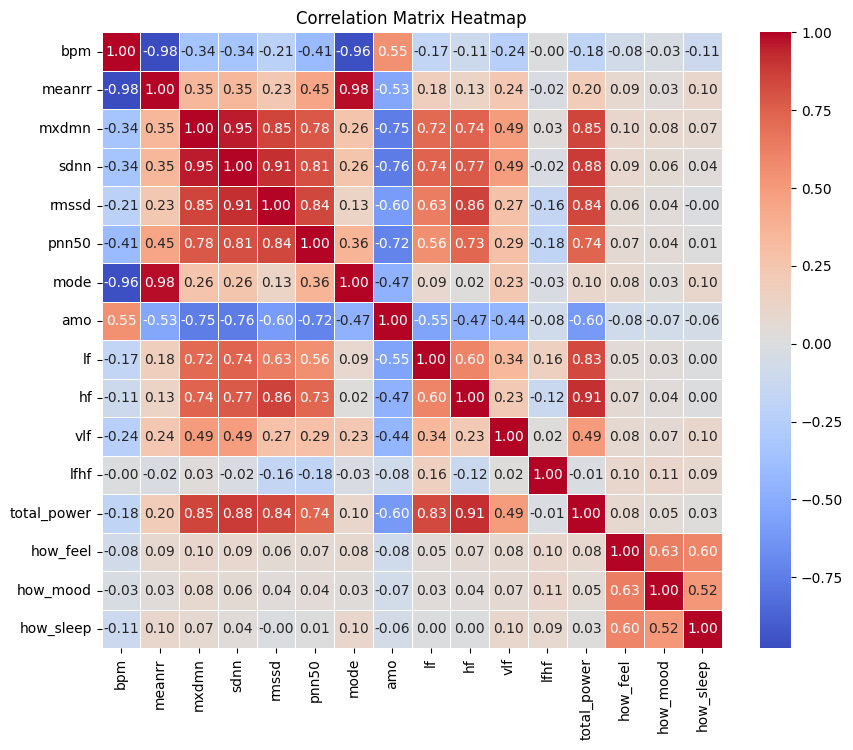

In [12]:
# Variable Relationships
print("\nVariable Relationships")
print("----------------------")
print("Correlation Matrix:")
correlation_matrix = df[numeric_columns].corr()
print(correlation_matrix)

# Visualize the Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

The heatmap tells us that all the key HRV measures (SDNN, RMSSD, HF, etc.) move together. Watching for several days of decline in these numbers is one of the clearest ways to spot possible early COVID-19 onset

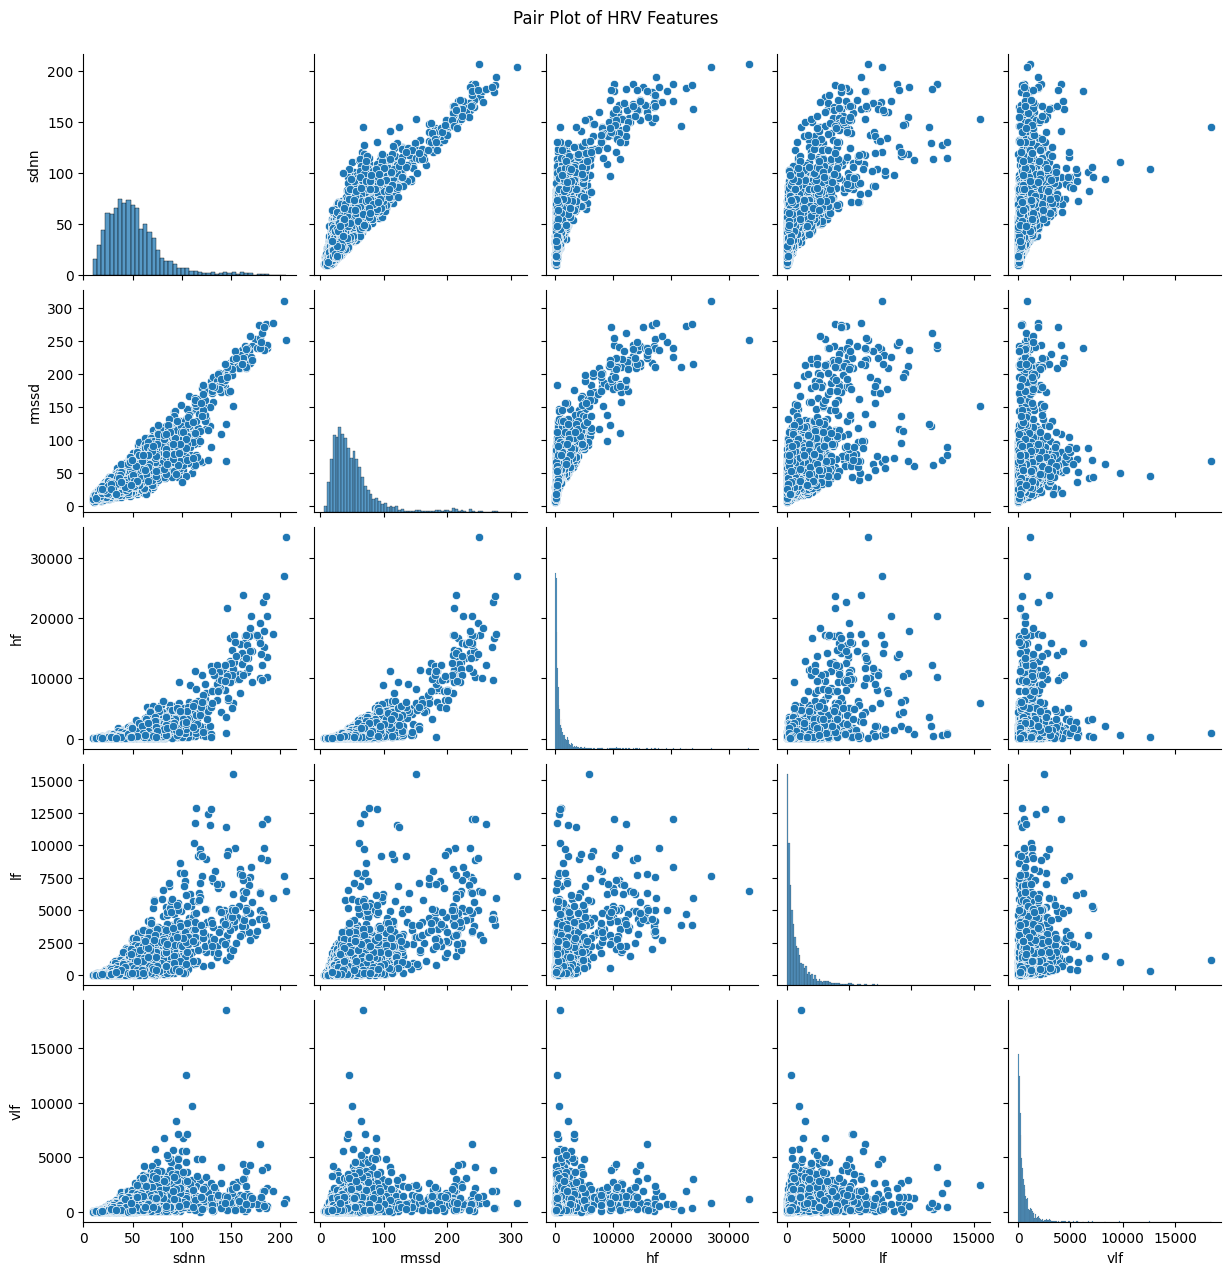

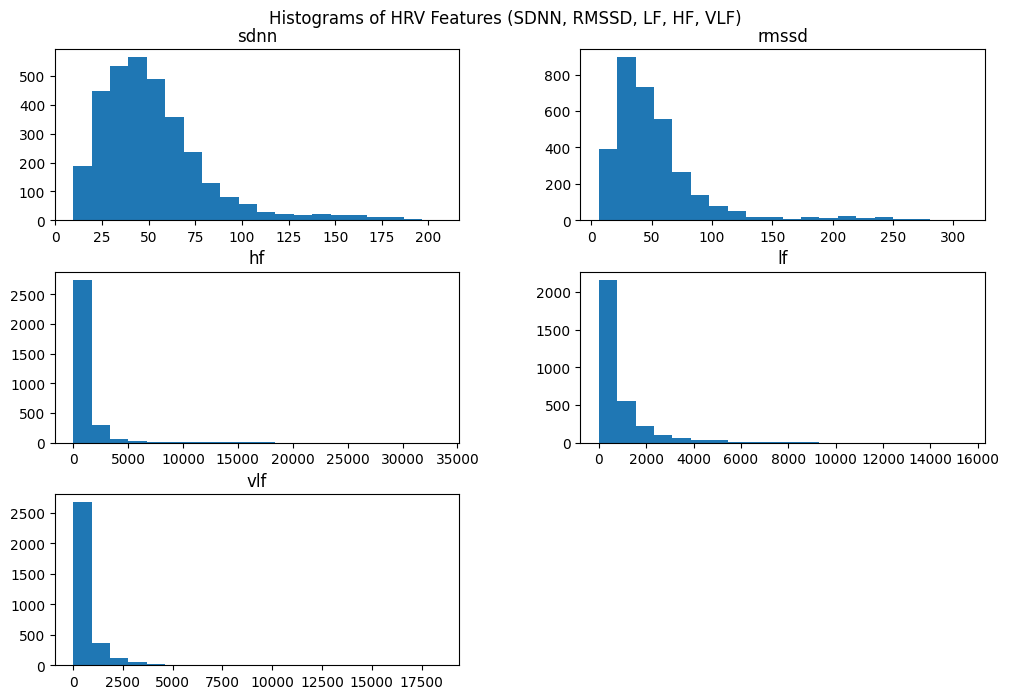

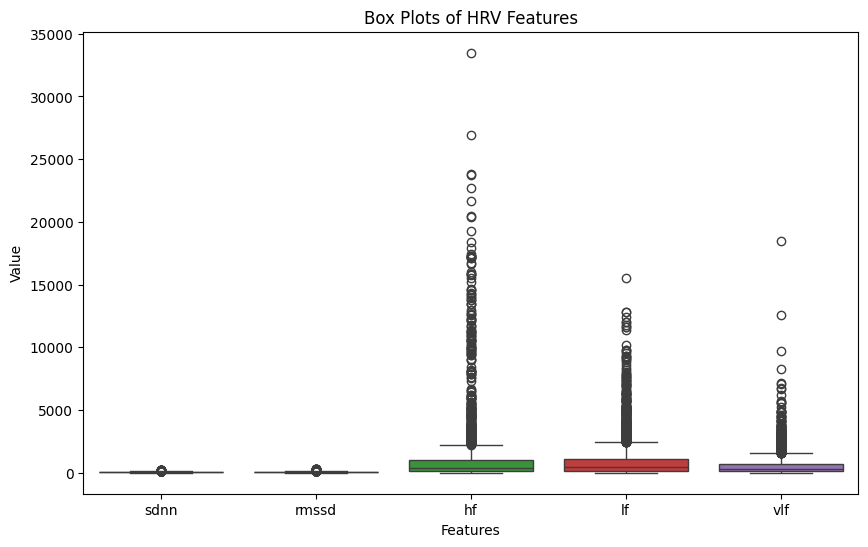

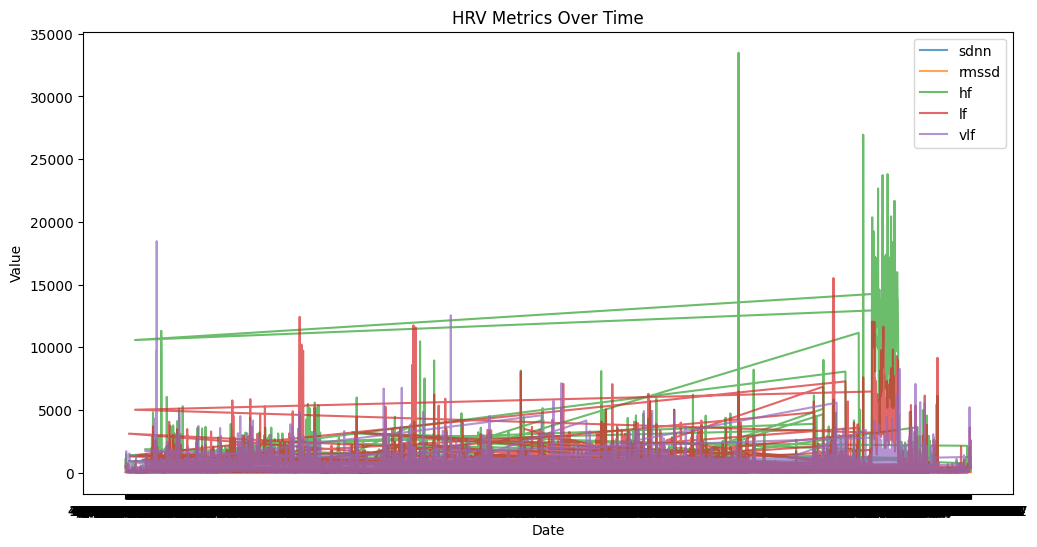

In [13]:
# Select numeric HRV features of interest
numeric_columns = ['sdnn', 'rmssd', 'hf', 'lf', 'vlf']

# --- Pairplot to see relationships between HRV measures ---
sns.pairplot(df[numeric_columns])
plt.suptitle('Pair Plot of HRV Features', y=1.02)
plt.show()

# --- Histograms of HRV distributions ---
df[numeric_columns].hist(bins=20, figsize=(12, 8), grid=False)
plt.suptitle('Histograms of HRV Features (SDNN, RMSSD, LF, HF, VLF)', y=0.93)
plt.show()

# --- Box plots to check for outliers ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numeric_columns])
plt.title('Box Plots of HRV Features')
plt.xlabel('Features')
plt.ylabel('Value')
plt.show()

# --- Time-series visualization for illness detection ---
plt.figure(figsize=(12, 6))
for col in ['sdnn', 'rmssd', 'hf', 'lf', 'vlf']:
    plt.plot(df['measurement_datetime'], df[col], label=col, alpha=0.7)

plt.title('HRV Metrics Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()


1.Pair Plot of HRV Features

What it shows:

SDNN, RMSSD, and HF are strongly positively related: when one is high, the others are also high.

LF and VLF also show moderate relationships.

This clustering means these metrics are telling a consistent story.

COVID insight:
Because SDNN, RMSSD, and HF move together, if all three start trending downward, it strengthens the signal of possible infection onset (compared to just one measure dropping).

2.Histograms of HRV Features

What it shows:

Most values for SDNN and RMSSD (time-domain variability) are clustered at lower ranges (20–60 ms), with fewer very high values.

HF, LF, and VLF (frequency features) are heavily skewed → most measurements are small, but some extreme spikes exist.

COVID insight:
If your SDNN or RMSSD drops lower than your usual baseline (closer to the left side of these histograms), it could mean your body is under stress — often an early sign of infection. Similarly, a fall in HF power (less activity in the “rest/digest” system) may suggest inflammation is starting.

3.Box Plots of HRV Features

What it shows:

SDNN and RMSSD values are fairly stable, with a few outliers.

HF, LF, and VLF have lots of outliers (huge spikes compared to most data).

This tells us the data is noisy — likely due to measurement differences across devices.

COVID insight:
Even with outliers, sustained downward shifts in SDNN, RMSSD, and HF are meaningful. When those consistently stay at the lower end of the box, it can signal reduced HRV from infection stress.

4.Time-Series Plot of HRV Metrics

What it shows:

HRV values bounce around a lot, but you can see periods of rising and falling trends for different users/days.

The important thing isn’t one point, but patterns over time.

COVID insight:
If you track an individual and see SDNN, RMSSD, and HF gradually dropping over several consecutive days, that’s a strong candidate for early COVID onset. Spikes in LF and VLF may not matter as much, but their sudden drops with HF are concerning.



New Feature :

1. Average over 3-7 days of SDNN, RMSSD, HF. If the average keeps falling, it indicates that the body is stressed from inflammation i.e. onset of COVID-19
sdnn_roll3d, rmssd_roll3d, hf_roll3d → 3-day trend.
sdnn_roll7d, rmssd_roll7d, hf_roll7d → 7-day trend.

2. Drop in the personal baseline of an individual user.
calculate their baseline (average of first 7 days)
Then compute: drop = (baseline - current) / baseline
eg: If SDNN goes from 50 → 30, that’s a 40% drop = 0.4.

Data Transformation

-Removing duplicate 
-Missing values are either forward or backward filled
-From the boxplots we see that HF, LF, VLF have extreme spikes (10,000+). These are likely sensor noise and outliers can distort rolling averages and mislead illness detection.

Strategies:

Z-score method: Drop points more than 3 standard deviations from the mean.

Percentile method: Winsorize (cap) values above the 99th percentile.

Domain knowledge: Set physiological limits (e.g., SDNN rarely > 200 ms in healthy adults).

In [25]:
 # ------------------------------
    # 1. Remove duplicate rows
    # ------------------------------


# Load your HRV dataset
df = pd.read_csv("hrv_measurements.csv", parse_dates=['measurement_datetime'])

# Ensure data is sorted by user and date
df = df.sort_values(by=['user_code', 'measurement_datetime'])

# ------------------------------
# 1. Create Rolling Averages
# ------------------------------
for col in ['sdnn', 'rmssd', 'hf']:
    df[f'{col}_roll3d'] = df.groupby('user_code')[col].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df[f'{col}_roll7d'] = df.groupby('user_code')[col].transform(lambda x: x.rolling(7, min_periods=1).mean())

# ------------------------------
# 2. Relative Drop from Baseline
# ------------------------------
# Define baseline as the user's first 7 days average
baseline = df.groupby('user_code').head(7).groupby('user_code')[['sdnn', 'rmssd', 'hf']].mean()

# Merge baseline back to main df
df = df.merge(baseline, on='user_code', suffixes=('', '_baseline'))

# Calculate relative drop (current vs baseline)
for col in ['sdnn', 'rmssd', 'hf']:
    df[f'{col}_drop'] = (df[f'{col}_baseline'] - df[col]) / df[f'{col}_baseline']

# ------------------------------
# Preview the new features
# ------------------------------
print(df[['user_code', 'measurement_datetime', 'sdnn', 'sdnn_roll3d', 'sdnn_roll7d', 'sdnn_drop']].head(15))

df = df.drop_duplicates()  # exact duplicates
df = df.drop_duplicates(subset=['user_code', 'measurement_datetime'], keep='first')

    # ------------------------------
    # 2. Handle missing values
    # ------------------------------
    # Drop columns with >50% missing values
df = df.dropna(axis=1, thresh=len(df) * 0.5)

    # Fill gaps per user (forward + backward fill)
df = (
        df.groupby('user_code')
          .apply(lambda group: group.ffill().bfill())
          .reset_index(drop=True)
          .copy()
    )

    # Interpolate for numeric HRV columns
hrv_cols = ['sdnn', 'rmssd', 'hf', 'lf', 'vlf']
for col in hrv_cols:
        if col in df.columns:
            df[col] = df[col].interpolate()

    # ------------------------------
    # 3. Handle outliers
    # ------------------------------
for col in hrv_cols:
        if col in df.columns:
            # Percentile clipping (1st–99th percentile)
            lower, upper = df[col].quantile([0.01, 0.99])
            df[col] = df[col].clip(lower, upper)

    # ------------------------------
    # 4. Sort data chronologically
    # ------------------------------
df['measurement_datetime'] = pd.to_datetime(df['measurement_datetime'], errors='coerce')
df = df.sort_values(by=['user_code', 'measurement_datetime'])

     user_code measurement_datetime    sdnn  sdnn_roll3d  sdnn_roll7d  \
0   007b8190cf  2020-04-21 21:23:00  45.802    45.802000    45.802000   
1   007b8190cf  2020-04-26 11:19:00  32.889    39.345500    39.345500   
2   013f6d3e5b  2020-05-15 04:14:00  54.811    54.811000    54.811000   
3   013f6d3e5b  2020-05-19 03:06:00  72.223    63.517000    63.517000   
4   01bad5a519  2019-12-31 09:07:00  29.650    29.650000    29.650000   
5   01bad5a519  2020-01-11 14:52:00  31.306    30.478000    30.478000   
6   01bad5a519  2020-01-30 17:55:00  33.033    31.329667    31.329667   
7   01bad5a519  2020-04-02 12:07:00  23.071    29.136667    29.265000   
8   01bad5a519  2020-04-12 15:00:00  23.613    26.572333    28.134600   
9   01bad5a519  2020-04-13 19:17:00  29.894    25.526000    28.427833   
10  01bad5a519  2020-04-17 08:47:00  33.887    29.131333    29.207714   
11  01bad5a519  2020-04-17 15:17:00  38.922    34.234333    30.532286   
12  01bad5a519  2020-04-20 20:34:00  29.848    34.2

C:\Users\som\AppData\Local\Temp\ipykernel_20992\24820054.py:49: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .apply(lambda group: group.ffill().bfill())
C:\Users\som\AppData\Local\Temp\ipykernel_20992\24820054.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.ffill().bfill())


Interpretation:
Negative sdnn_drop = strong recovery/resilience.
Positive sdnn_drop (esp. >0.2) = possible early illness or stress.
Sustained positive values across rolling averages = warning of COVID-19 onset.

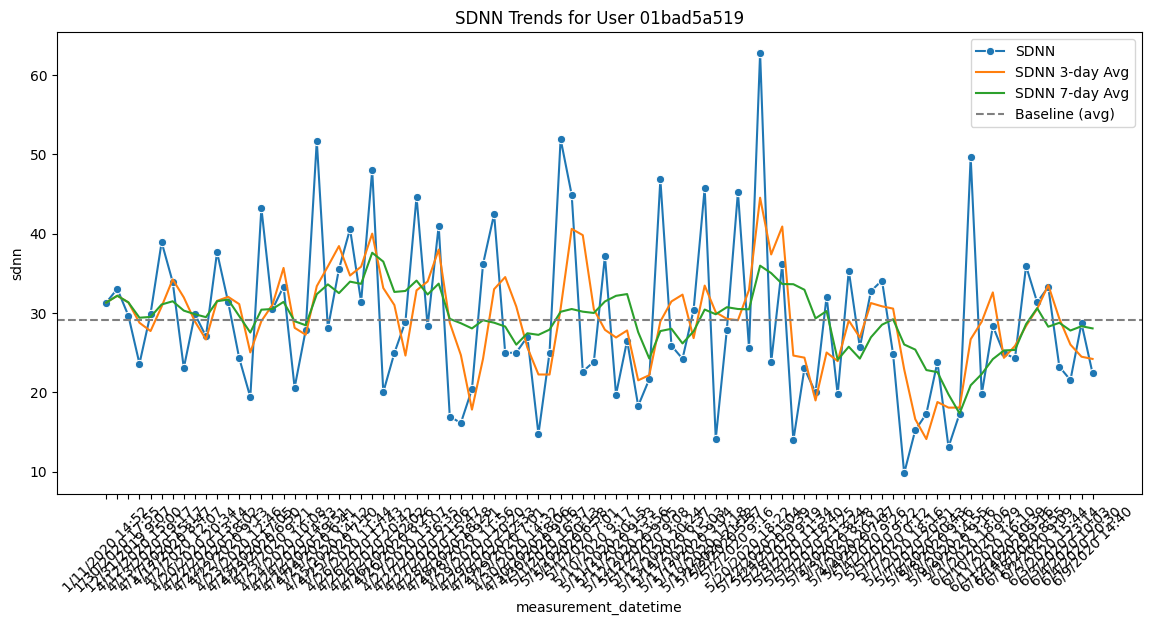

In [16]:
# Pick a single user for visualization
user_id = "01bad5a519"
user_data = df[df['user_code'] == user_id].sort_values(by='measurement_datetime')

# Plot SDNN, RMSSD, HF with rolling averages
plt.figure(figsize=(14, 6))
sns.lineplot(data=user_data, x='measurement_datetime', y='sdnn', label='SDNN', marker="o")
sns.lineplot(data=user_data, x='measurement_datetime', y='sdnn_roll3d', label='SDNN 3-day Avg')
sns.lineplot(data=user_data, x='measurement_datetime', y='sdnn_roll7d', label='SDNN 7-day Avg')

plt.axhline(user_data['sdnn'].mean(), color='gray', linestyle='--', label='Baseline (avg)')
plt.title(f"SDNN Trends for User {user_id}")
plt.xticks(rotation=45)
plt.legend()
plt.show()

Interpretation:
For the individaul, user_code=01bad5a519
The baseline is around 30 ms.
The 3-day and 7-day averages often dip below baseline, meaning this person frequently has lower-than-normal SDNN. This kind of downward shift could indicate body stress or inflammation — possible early illness (like COVID onset).
The 7-day average trends downward toward the end, suggesting this user is gradually weakening compared to baseline.

Data Quality Assessment

1. Data Profiling
The dataset contains HRV measures (sdnn, rmssd, hf, lf, vlf) along with metadata (user_code, measurement_datetime).
Numeric features show skewed distributions (as seen in histograms). For example, HF, LF, and VLF have many very small values and a few very large outliers.
Time-series patterns are irregular: some users have dense measurements, while others have sparse or scattered entries.

2. Data Completeness
Not all users had filled in all data columns. The missing values make it harder to track accurately.
Frequency-domain features (HF, LF, VLF) sometimes have missing values when the signal quality from sensors was poor.

3. Data Accuracy
Since these readings are self-reported there could be bias as the symptoms are not clinically verified.
The HRV readings taken by the devices could also have a margin of error due to - movement of arm or poor sensors.

4. Data Consistency
Units and scales appear consistent across the dataset (e.g., SDNN in milliseconds, frequency-domain features in ms²).
However, measurement frequency varies between users — some measure daily, others only occasionally.
Different devices (Apple Watch, Garmin, smartphone PPG) may record HRV slightly differently, creating consistency challenges.

5. Data Integrity
Each row is tied to a user_code and measurement_datetime, which preserves integrity by uniquely identifying measurements.
Duplicate values were removed. Missing values were forward/backward filled and the data was sorted chronologically (day-noon-night).


SDNN (Standard Deviation of NN intervals, a heart-rate variability measure) can help detect COVID because the virus often disrupts the autonomic nervous system, causing abnormal heartbeat patterns.
By spotting unusual variability in heartbeat intervals, SDNN can serve as an early, non-invasive signal of infection.
Using the feature of rolling average we have seen for one user the variations in 3-7 intervals and how it can be used as an indication for COVID onset.

Citation: Parts of the code and visual interpretations were generated using Chat GPT